In [1]:
# ============================================================
# LCA-Emissionsberechnung auf Basis gespeicherter Flottenmodell-Ergebnisse
# ============================================================

import pandas as pd
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


# ============================================================
# 1. Zentraler Parameterblock
# ============================================================

RESULTS_DIR = Path("Results")
CONFIG_PATH = Path("fleet_model_config.json")
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

NEW_VEHICLES_PATH = RESULTS_DIR / "policy_new_vehicles_all.csv"
FINAL_STOCK_PATH = RESULTS_DIR / "policy_final_stock_all.csv"
EXITS_PATH = RESULTS_DIR / "policy_exits_all.csv"
HISTORICAL_EXITS_PATH = Path("../Data/321-140-17133-26-ABS.csv")

# Pfad zur separaten Emissionsparameterdatei einfach hier anpassen
EMISSION_PARAMS_PATH = Path("LCA_Emissions_Python.csv")

# Zentrale Annahmen
ANNUAL_KM_PER_VEHICLE = 12_500
ANALYSIS_START_YEAR = 2025
ANALYSIS_END_YEAR = 2050

# Zeitliche Zuordnung der Emissionen
PRODUCTION_YEAR_OFFSET = -1   # Produktionsemissionen: Jahr der Erstzulassung - 1
USE_YEAR_OFFSET = 0           # Nutzungsemissionen: Jahr
EOL_YEAR_OFFSET = 1           # End-of-Life-Emissionen: Jahr + 1

# CSV-Einstellungen
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"

# Output-Dateien
OUT_PREPARED_NEW_VEHICLES = RESULTS_DIR / "prepared_new_vehicles_lca.csv"
OUT_PREPARED_FINAL_STOCK = RESULTS_DIR / "prepared_final_stock_lca.csv"
OUT_PREPARED_EXITS = RESULTS_DIR / "prepared_exits_lca.csv"

OUT_EMISSIONS_BY_PHASE = RESULTS_DIR / "emissions_by_phase.csv"
OUT_SUMMARY_YEAR_PHASE = RESULTS_DIR / "emissions_summary_by_year_phase.csv"
OUT_SUMMARY_YEAR_TOTAL = RESULTS_DIR / "emissions_summary_by_year_total.csv"
OUT_SUMMARY_TOTAL_SCENARIO = RESULTS_DIR / "emissions_summary_total_by_scenario.csv"


# ============================================================
# 2. Mapping-Definitionen
# ============================================================

SEGMENT_TO_SIZE_CLASS = {
    "Minis": "Small",
    "Kleinwagen": "Small",

    "Kompaktklasse": "Medium",
    "Mittelklasse": "Medium",
    "Mini-Vans": "Medium",
    "Sonstige": "Medium",

    "Obere Mittelklasse": "Large",
    "Oberklasse": "Large",
    "SUVs": "Large",
    "Geländewagen": "Large",
    "Sportwagen": "Large",
    "Großraum-Vans": "Large",
    "Utilities": "Large",
    "Wohnmobile": "Large",
}

ANTRIEBSART_TO_DRIVETRAIN_GROUP = {
    "Elektro (BEV)": "BEV",
    "Benzin": "ICE_Petrol",
    "Diesel": "ICE_Diesel",
    "Hybrid": "ICE_Petrol",
    "Erdgas (CNG) (einschl. bivalent)": "ICE_Petrol",
    "Flüssiggas (LPG) (einschl. bivalent)": "ICE_Petrol",
    "Sonstige": "ICE_Petrol",
}

PARAM_DRIVETRAIN_STANDARDIZATION = {
    "BEV": "BEV",
    "ICEVs-Petrol": "ICE_Petrol",
    "ICEVs-Diesel": "ICE_Diesel",
}


# ============================================================
# 3. Hilfsfunktionen
# ============================================================

def read_semicolon_csv(path: Path) -> pd.DataFrame:
    """
    Lädt eine CSV-Datei mit Semikolon-Trennzeichen und utf-8-sig-Encoding.
    """
    if not path.exists():
        raise FileNotFoundError(f"Datei nicht gefunden: {path}")

    return pd.read_csv(
        path,
        sep=CSV_SEP,
        encoding=CSV_ENCODING,
    )


def parse_german_numeric_series(series: pd.Series) -> pd.Series:
    """
    Wandelt numerische Spalten robust in float um.

    Unterstützt u. a.:
    - deutsche Dezimalkommas: 5,00
    - deutsche Tausenderpunkte: 1.234,56
    - normale Punkte: 1234.56
    - bereits numerische Werte
    """
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)

    s = (
        series.astype(str)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )

    def convert_value(x):
        if pd.isna(x):
            return np.nan

        x = str(x).strip()

        # Wenn ein Komma enthalten ist, interpretieren wir es als deutsches Dezimalzeichen.
        if "," in x:
            x = x.replace(".", "")
            x = x.replace(",", ".")

        return pd.to_numeric(x, errors="coerce")

    return s.apply(convert_value).astype(float)


def require_columns(df: pd.DataFrame, required_columns: list[str], df_name: str) -> None:
    """
    Prüft, ob alle benötigten Spalten vorhanden sind.
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(
            f"In Tabelle '{df_name}' fehlen folgende Spalten: {missing}\n"
            f"Vorhandene Spalten: {list(df.columns)}"
        )


def add_lca_mapping_columns(df: pd.DataFrame, df_name: str) -> pd.DataFrame:
    """
    Ergänzt Flottentabellen um:
    - size_class
    - drivetrain_group_std
    """
    df = df.copy()

    require_columns(df, ["Segment", "Antriebsart"], df_name)

    df["size_class"] = df["Segment"].map(SEGMENT_TO_SIZE_CLASS)
    df["drivetrain_group_std"] = df["Antriebsart"].map(ANTRIEBSART_TO_DRIVETRAIN_GROUP)

    missing_size = df.loc[df["size_class"].isna(), "Segment"].dropna().unique()
    missing_drive = df.loc[df["drivetrain_group_std"].isna(), "Antriebsart"].dropna().unique()

    if len(missing_size) > 0:
        print(
            f"Warnung: Für folgende Segmente in '{df_name}' fehlt ein size_class-Mapping. "
            f"Diese Zeilen können später keine Emissionsparameter erhalten:\n{missing_size}"
        )

    if len(missing_drive) > 0:
        print(
            f"Warnung: Für folgende Antriebsarten in '{df_name}' fehlt ein drivetrain_group_std-Mapping. "
            f"Diese Zeilen können später keine Emissionsparameter erhalten:\n{missing_drive}"
        )

    return df


def load_emission_parameters(path: Path) -> pd.DataFrame:
    """
    Lädt die Emissionsparameter im breiten Format, bereinigt numerische Werte
    und bringt sie in ein langes Format.

    Ergebnis enthält:
    - Parameter
    - vehicle_type_raw
    - value
    - drivetrain_group_raw
    - drivetrain_group_std
    - size_class
    """
    params_wide = read_semicolon_csv(path)

    require_columns(
        params_wide,
        ["Parameter", "Explanation_parameter"],
        "LCA_Emissions_Python.csv"
    )

    id_cols = ["Parameter", "Explanation_parameter"]
    value_cols = [col for col in params_wide.columns if col not in id_cols]

    params_long = params_wide.melt(
        id_vars=id_cols,
        value_vars=value_cols,
        var_name="vehicle_type_raw",
        value_name="value_raw",
    )

    params_long["value"] = parse_german_numeric_series(params_long["value_raw"])

    # Kombinationen wie BEV_small oder ICEVs-Diesel_large trennen
    split_cols = params_long["vehicle_type_raw"].str.rsplit("_", n=1, expand=True)
    params_long["drivetrain_group_raw"] = split_cols[0]
    params_long["size_class_raw"] = split_cols[1]

    params_long["drivetrain_group_std"] = params_long["drivetrain_group_raw"].map(
        PARAM_DRIVETRAIN_STANDARDIZATION
    )

    params_long["size_class"] = (
        params_long["size_class_raw"]
        .str.strip()
        .str.lower()
        .map({
            "small": "Small",
            "medium": "Medium",
            "large": "Large",
        })
    )

    missing_drive = params_long.loc[
        params_long["drivetrain_group_std"].isna(),
        "drivetrain_group_raw"
    ].dropna().unique()

    missing_size = params_long.loc[
        params_long["size_class"].isna(),
        "size_class_raw"
    ].dropna().unique()

    if len(missing_drive) > 0:
        print(
            "Warnung: Für folgende Emissionsparameter-Antriebsgruppen fehlt eine Standardisierung:\n"
            f"{missing_drive}"
        )

    if len(missing_size) > 0:
        print(
            "Warnung: Für folgende Emissionsparameter-Größenklassen fehlt eine Standardisierung:\n"
            f"{missing_size}"
        )

    return params_long


def create_parameter_lookup(params_long: pd.DataFrame) -> pd.DataFrame:
    """
    Erzeugt eine breite Lookup-Tabelle mit je einer Zeile pro
    drivetrain_group_std / size_class und je einer Spalte pro Parameter.
    """
    lookup = (
        params_long
        .pivot_table(
            index=["drivetrain_group_std", "size_class"],
            columns="Parameter",
            values="value",
            aggfunc="first",
        )
        .reset_index()
    )

    lookup.columns.name = None
    return lookup


def merge_params(
    df: pd.DataFrame,
    params_lookup: pd.DataFrame,
    required_params: list[str],
    df_name: str,
) -> pd.DataFrame:
    """
    Verknüpft Fahrzeugdaten mit Emissionsparametern.

    Fehlende Parameterwerte werden mit 0.0 ersetzt und als Warnung ausgegeben.
    """
    df = df.copy()

    df = df.merge(
        params_lookup,
        on=["drivetrain_group_std", "size_class"],
        how="left",
    )

    for param in required_params:
        if param not in df.columns:
            print(
                f"Warnung: Parameter '{param}' ist in der Emissionsparameterdatei nicht vorhanden. "
                f"Er wird in '{df_name}' mit 0.0 angesetzt."
            )
            df[param] = 0.0
        else:
            missing_count = df[param].isna().sum()
            if missing_count > 0:
                print(
                    f"Warnung: In '{df_name}' fehlen {missing_count} Werte für Parameter '{param}'. "
                    f"Fehlende Werte werden mit 0.0 ersetzt."
                )
                df[param] = df[param].fillna(0.0)

    return df


def ensure_numeric_column(df: pd.DataFrame, column: str, df_name: str) -> pd.DataFrame:
    """
    Wandelt eine Spalte in numerische Werte um.
    """
    df = df.copy()

    if column not in df.columns:
        raise ValueError(
            f"In Tabelle '{df_name}' fehlt die benötigte Spalte '{column}'. "
            f"Vorhandene Spalten: {list(df.columns)}"
        )

    df[column] = parse_german_numeric_series(df[column]).fillna(0.0)
    return df


def get_registration_year_column(df: pd.DataFrame) -> str | None:
    """
    Gibt die Spalte für das Jahr der Erstzulassung zurück, falls vorhanden.
    """
    candidates = [
        "Jahr der Erstzulassung",
        "Jahr_der_Erstzulassung",
        "Erstzulassungsjahr",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    return None


# ============================================================
# 4. Input-Daten laden
# ============================================================

new_vehicles = read_semicolon_csv(NEW_VEHICLES_PATH)
final_stock = read_semicolon_csv(FINAL_STOCK_PATH)
exits = read_semicolon_csv(EXITS_PATH)
historical_exits = pd.read_csv(HISTORICAL_EXITS_PATH, sep=CSV_SEP, encoding="latin1")

emission_params_long = load_emission_parameters(EMISSION_PARAMS_PATH)
emission_params_lookup = create_parameter_lookup(emission_params_long)

print("Geladene Tabellen:")
print(f"- new_vehicles: {new_vehicles.shape}")
print(f"- final_stock:  {final_stock.shape}")
print(f"- exits:        {exits.shape}")
print(f"- historical_exits: {historical_exits.shape}")
print(f"- emission_params_long: {emission_params_long.shape}")
print(f"- emission_params_lookup: {emission_params_lookup.shape}")


# ============================================================
# 5. Flottentabellen vorbereiten und speichern
# ============================================================

new_vehicles_prepared = add_lca_mapping_columns(new_vehicles, "policy_new_vehicles_all.csv")
final_stock_prepared = add_lca_mapping_columns(final_stock, "policy_final_stock_all.csv")
exits_prepared = add_lca_mapping_columns(exits, "policy_exits_all.csv")

new_vehicles_prepared.to_csv(
    OUT_PREPARED_NEW_VEHICLES,
    sep=CSV_SEP,
    encoding=CSV_ENCODING,
    index=False,
)

final_stock_prepared.to_csv(
    OUT_PREPARED_FINAL_STOCK,
    sep=CSV_SEP,
    encoding=CSV_ENCODING,
    index=False,
)

exits_prepared.to_csv(
    OUT_PREPARED_EXITS,
    sep=CSV_SEP,
    encoding=CSV_ENCODING,
    index=False,
)

print("Vorbereitete LCA-Flottentabellen gespeichert:")
print(f"- {OUT_PREPARED_NEW_VEHICLES}")
print(f"- {OUT_PREPARED_FINAL_STOCK}")
print(f"- {OUT_PREPARED_EXITS}")


# ============================================================
# 6. Produktionsemissionen berechnen
# ============================================================

require_columns(
    new_vehicles_prepared,
    ["Szenario", "Jahr", "Segment", "Antriebsart", "neue_fahrzeuge"],
    "prepared_new_vehicles_lca.csv",
)

prod = ensure_numeric_column(
    new_vehicles_prepared,
    "neue_fahrzeuge",
    "prepared_new_vehicles_lca.csv",
)

prod = merge_params(
    prod,
    emission_params_lookup,
    required_params=["Vehicle_production", "Battery_production", "Battery_capacity"],
    df_name="production",
)

registration_year_col = get_registration_year_column(prod)

if registration_year_col is not None:
    prod["emission_year"] = parse_german_numeric_series(prod[registration_year_col]) + PRODUCTION_YEAR_OFFSET
else:
    print(
        "Hinweis: Spalte 'Jahr der Erstzulassung' fehlt. "
        "Für Produktionsemissionen wird ersatzweise Jahr - 1 verwendet."
    )
    prod["emission_year"] = parse_german_numeric_series(prod["Jahr"]) + PRODUCTION_YEAR_OFFSET

prod["phase"] = "production"
prod["vehicles"] = prod["neue_fahrzeuge"]
prod["emissions_tco2e"] = prod["neue_fahrzeuge"] * prod["Vehicle_production"]

production_emissions = prod[
    [
        "Szenario",
        "emission_year",
        "phase",
        "Segment",
        "Antriebsart",
        "drivetrain_group_std",
        "size_class",
        "vehicles",
        "emissions_tco2e",
    ]
].copy()

# Batterieproduktion nur für neu zugelassene BEVs:
# kgCO2e/kWh * kWh / 1.000 = tCO2e pro Fahrzeug.
is_bev_production = prod["drivetrain_group_std"].eq("BEV")
missing_battery_params = prod.loc[
    is_bev_production, ["Battery_production", "Battery_capacity"]
].isna().any(axis=1)
if missing_battery_params.any():
    missing_types = (
        prod.loc[is_bev_production & missing_battery_params, ["size_class"]]
        .drop_duplicates()["size_class"].tolist()
    )
    raise ValueError(f"Fehlende Batterieparameter für BEV-Größenklassen: {missing_types}")

battery_prod = prod.copy()
battery_prod["phase"] = "battery_production"
battery_prod["emissions_tco2e"] = np.where(
    is_bev_production,
    battery_prod["neue_fahrzeuge"]
    * battery_prod["Battery_production"]
    * battery_prod["Battery_capacity"]
    / 1_000.0,
    0.0,
)
battery_production_emissions = battery_prod[
    [
        "Szenario", "emission_year", "phase", "Segment",
        "Antriebsart", "drivetrain_group_std", "size_class",
        "vehicles", "emissions_tco2e",
    ]
].copy()


# ============================================================
# 7. Nutzungsemissionen berechnen
# ============================================================

require_columns(
    final_stock_prepared,
    ["Szenario", "Jahr", "Segment", "Antriebsart", "finaler_bestand"],
    "prepared_final_stock_lca.csv",
)

use = ensure_numeric_column(
    final_stock_prepared,
    "finaler_bestand",
    "prepared_final_stock_lca.csv",
)

use = merge_params(
    use,
    emission_params_lookup,
    required_params=[
        "Consumption",
        "WTT",
        "TTW",
        "Maintenance in gCO2e/km",
    ],
    df_name="use",
)

use["emission_year"] = parse_german_numeric_series(use["Jahr"]) + USE_YEAR_OFFSET
use["phase"] = "use"
use["vehicles"] = use["finaler_bestand"]

electricity_mix_path = {
    int(year): float(value)
    for year, value in config["ghg"]["electricity_mix_gco2e_per_kwh"].items()
}
required_electricity_years = set(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))
missing_electricity_years = sorted(required_electricity_years.difference(electricity_mix_path))
if missing_electricity_years:
    raise ValueError(f"Im Strommixpfad fehlen Jahre: {missing_electricity_years}")
use["electricity_mix_gco2e_per_kwh"] = use["emission_year"].map(electricity_mix_path)

# gCO2e/km für Nutzung
# BEV:
#   Consumption = kWh/100 km
#   electricity_mix_gco2e_per_kwh = jahresspezifische gCO2e/kWh aus der Config
#
# Benzin / Diesel:
#   Consumption = Liter/100 km
#   WTT und TTW = gCO2e/Liter
#
# Maintenance wird in beiden Fällen direkt als gCO2e/km addiert.

is_bev = use["drivetrain_group_std"].eq("BEV")

use["use_emissions_gco2e_per_km"] = np.where(
    is_bev,
    (use["Consumption"] / 100.0) * use["electricity_mix_gco2e_per_kwh"]
    + use["Maintenance in gCO2e/km"],
    (use["Consumption"] / 100.0) * (use["WTT"] + use["TTW"])
    + use["Maintenance in gCO2e/km"],
)

# Umrechnung:
# Fahrzeuge * km/Jahr * gCO2e/km = gCO2e
# gCO2e / 1_000_000 = tCO2e
use["emissions_tco2e"] = (
    use["finaler_bestand"]
    * ANNUAL_KM_PER_VEHICLE
    * use["use_emissions_gco2e_per_km"]
    / 1_000_000.0
)

use_emissions = use[
    [
        "Szenario",
        "emission_year",
        "phase",
        "Segment",
        "Antriebsart",
        "drivetrain_group_std",
        "size_class",
        "vehicles",
        "emissions_tco2e",
    ]
].copy()


# ============================================================
# 8. End-of-Life-Emissionen berechnen
# ============================================================

require_columns(
    exits_prepared,
    ["Szenario", "Jahr", "Segment", "Antriebsart", "exits"],
    "prepared_exits_lca.csv",
)

eol = ensure_numeric_column(
    exits_prepared,
    "exits",
    "prepared_exits_lca.csv",
)

eol = merge_params(
    eol,
    emission_params_lookup,
    required_params=["End_of_life"],
    df_name="end_of_life",
)

eol["emission_year"] = parse_german_numeric_series(eol["Jahr"]) + EOL_YEAR_OFFSET
eol["phase"] = "end_of_life"
eol["vehicles"] = eol["exits"]
eol["emissions_tco2e"] = eol["exits"] * eol["End_of_life"]

eol_emissions = eol[
    [
        "Szenario",
        "emission_year",
        "phase",
        "Segment",
        "Antriebsart",
        "drivetrain_group_std",
        "size_class",
        "vehicles",
        "emissions_tco2e",
    ]
].copy()

# Historische ABS schließen den Beginn der EoL-Zeitreihe:
# ABS 2024 -> EoL 2025 und ABS 2025 -> EoL 2026.
# Ab ABS/Exit 2026 stammen die Werte aus dem Flottenmodell und erscheinen 2027.
historical_eol = historical_exits.loc[
    historical_exits["Berichtsjahr"].isin([2024, 2025]),
    ["Berichtsjahr", "Segment", "Antriebsart", "Anzahl"],
].copy()
historical_eol = add_lca_mapping_columns(historical_eol, "historische ABS 2024/2025")
historical_eol = historical_eol.rename(columns={"Anzahl": "exits"})
historical_eol = ensure_numeric_column(historical_eol, "exits", "historische ABS 2024/2025")
historical_eol = merge_params(
    historical_eol, emission_params_lookup, required_params=["End_of_life"],
    df_name="historical_end_of_life",
)
historical_eol["emission_year"] = historical_eol["Berichtsjahr"] + EOL_YEAR_OFFSET
historical_eol["phase"] = "end_of_life"
historical_eol["vehicles"] = historical_eol["exits"]
historical_eol["emissions_tco2e"] = historical_eol["exits"] * historical_eol["End_of_life"]
scenario_names = pd.DataFrame({"Szenario": sorted(final_stock_prepared["Szenario"].unique())})
historical_eol = historical_eol.merge(scenario_names, how="cross")
historical_eol_emissions = historical_eol[
    ["Szenario", "emission_year", "phase", "Segment", "Antriebsart",
     "drivetrain_group_std", "size_class", "vehicles", "emissions_tco2e"]
].copy()
eol_emissions = pd.concat([historical_eol_emissions, eol_emissions], ignore_index=True)


# ============================================================
# 9. Gemeinsame Ergebnistabelle emissions_by_phase
# ============================================================

emissions_by_phase = pd.concat(
    [
        production_emissions,
        battery_production_emissions,
        use_emissions,
        eol_emissions,
    ],
    ignore_index=True,
)

emissions_by_phase["emission_year"] = emissions_by_phase["emission_year"].astype(int)
emissions_by_phase["vehicles"] = emissions_by_phase["vehicles"].fillna(0.0)
emissions_by_phase["emissions_tco2e"] = emissions_by_phase["emissions_tco2e"].fillna(0.0)

# Das Flottenmodell läuft bis 2051, damit dessen Produktion im Jahr 2050
# bilanziert werden kann. Die veröffentlichte GHG-Zeitreihe endet bei 2050.
emissions_by_phase = emissions_by_phase.loc[
    emissions_by_phase["emission_year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()

emissions_by_phase = emissions_by_phase.sort_values(
    [
        "Szenario",
        "emission_year",
        "phase",
        "Segment",
        "Antriebsart",
    ]
).reset_index(drop=True)

emissions_by_phase.head()

Geladene Tabellen:
- new_vehicles: (8424, 11)
- final_stock:  (355759, 7)
- exits:        (339819, 7)
- historical_exits: (21219, 5)
- emission_params_long: (81, 9)
- emission_params_lookup: (9, 11)


Vorbereitete LCA-Flottentabellen gespeichert:
- Results\prepared_new_vehicles_lca.csv
- Results\prepared_final_stock_lca.csv
- Results\prepared_exits_lca.csv
Warnung: In 'production' fehlen 6240 Werte für Parameter 'Battery_production'. Fehlende Werte werden mit 0.0 ersetzt.
Warnung: In 'production' fehlen 6240 Werte für Parameter 'Battery_capacity'. Fehlende Werte werden mit 0.0 ersetzt.
Warnung: In 'use' fehlen 73926 Werte für Parameter 'WTT'. Fehlende Werte werden mit 0.0 ersetzt.
Warnung: In 'use' fehlen 73926 Werte für Parameter 'TTW'. Fehlende Werte werden mit 0.0 ersetzt.
Warnung: Parameter 'Maintenance in gCO2e/km' ist in der Emissionsparameterdatei nicht vorhanden. Er wird in 'use' mit 0.0 angesetzt.


,Szenario,emission_year,phase,Segment,Antriebsart,drivetrain_group_std,size_class,vehicles,emissions_tco2e
0,abwrackpraemie,2025,battery_production,Geländewagen,Benzin,ICE_Petrol,Large,32292.639030,0.000000
1,abwrackpraemie,2025,battery_production,Geländewagen,Diesel,ICE_Diesel,Large,58032.682886,0.000000
2,abwrackpraemie,2025,battery_production,Geländewagen,Elektro (BEV),BEV,Large,16024.174903,129795.816712
3,abwrackpraemie,2025,battery_production,Geländewagen,Hybrid,ICE_Petrol,Large,252740.662371,0.000000
4,abwrackpraemie,2025,battery_production,Großraum-Vans,Benzin,ICE_Petrol,Large,15165.495132,0.000000


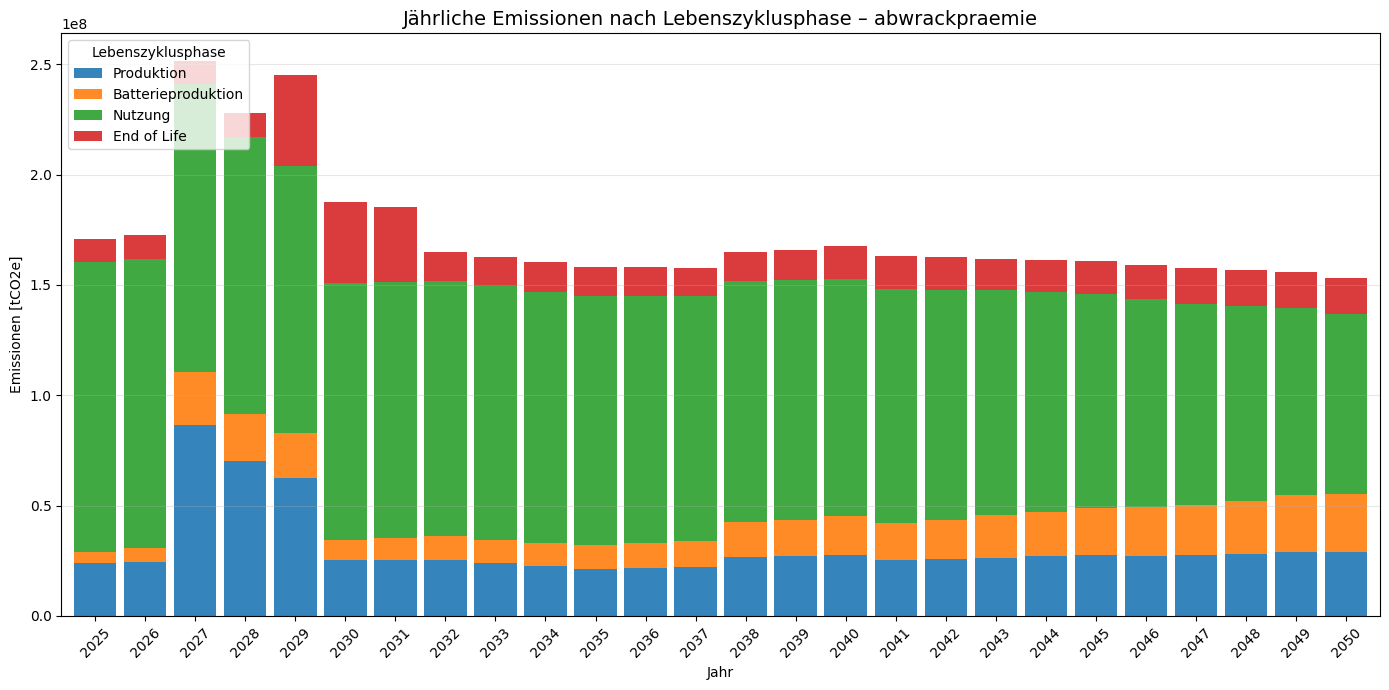

Diagramm gespeichert: Results\emissions_area_abwrackpraemie.png


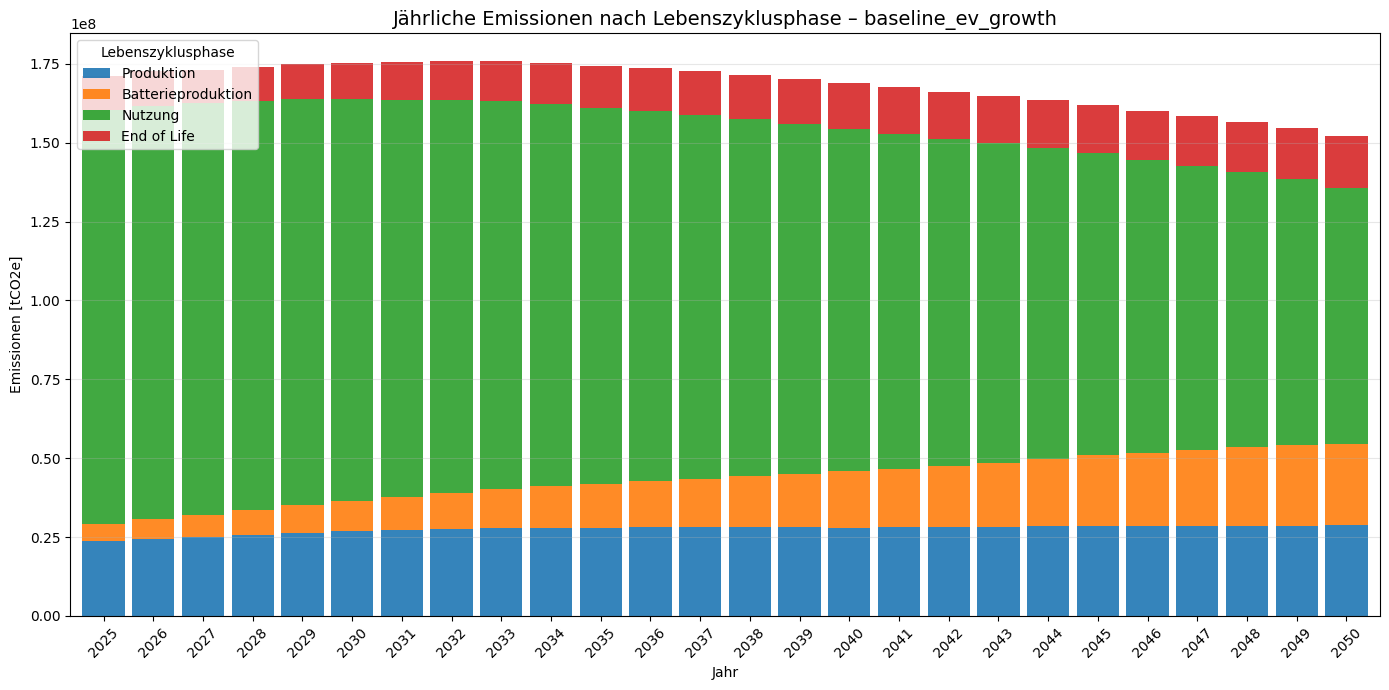

Diagramm gespeichert: Results\emissions_area_baseline_ev_growth.png


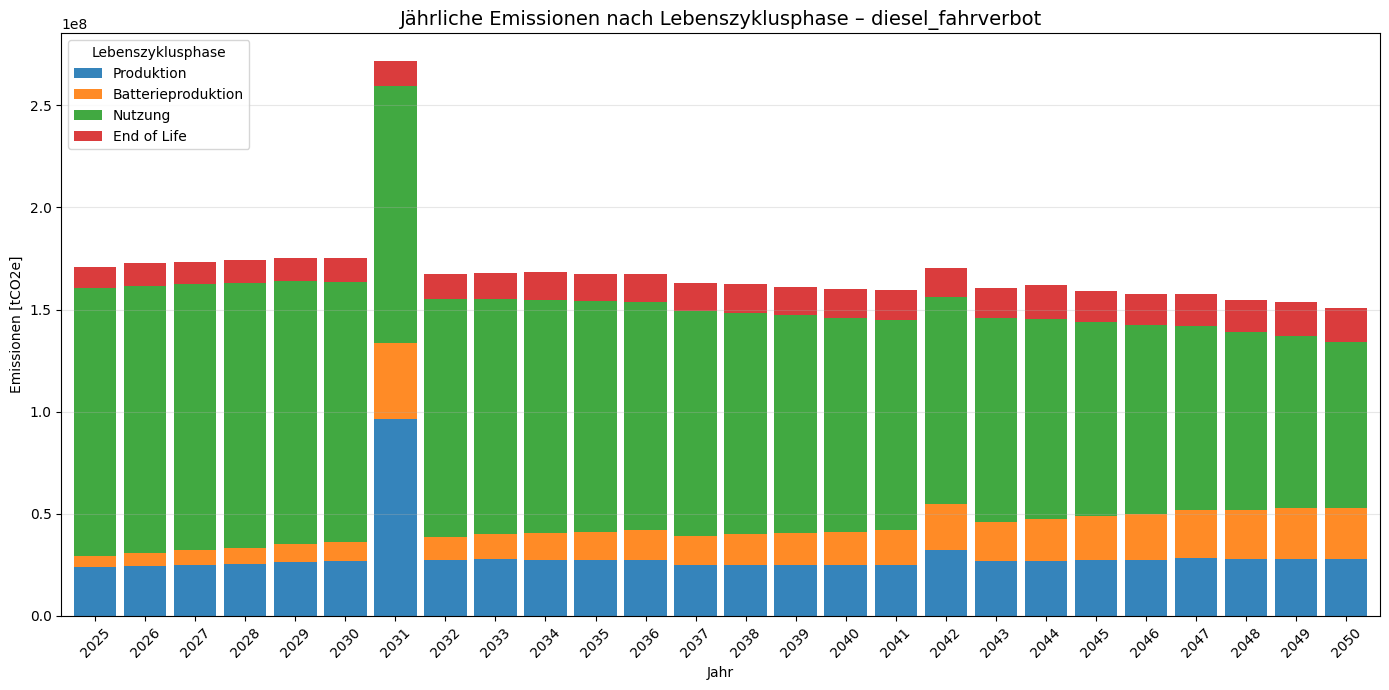

Diagramm gespeichert: Results\emissions_area_diesel_fahrverbot.png


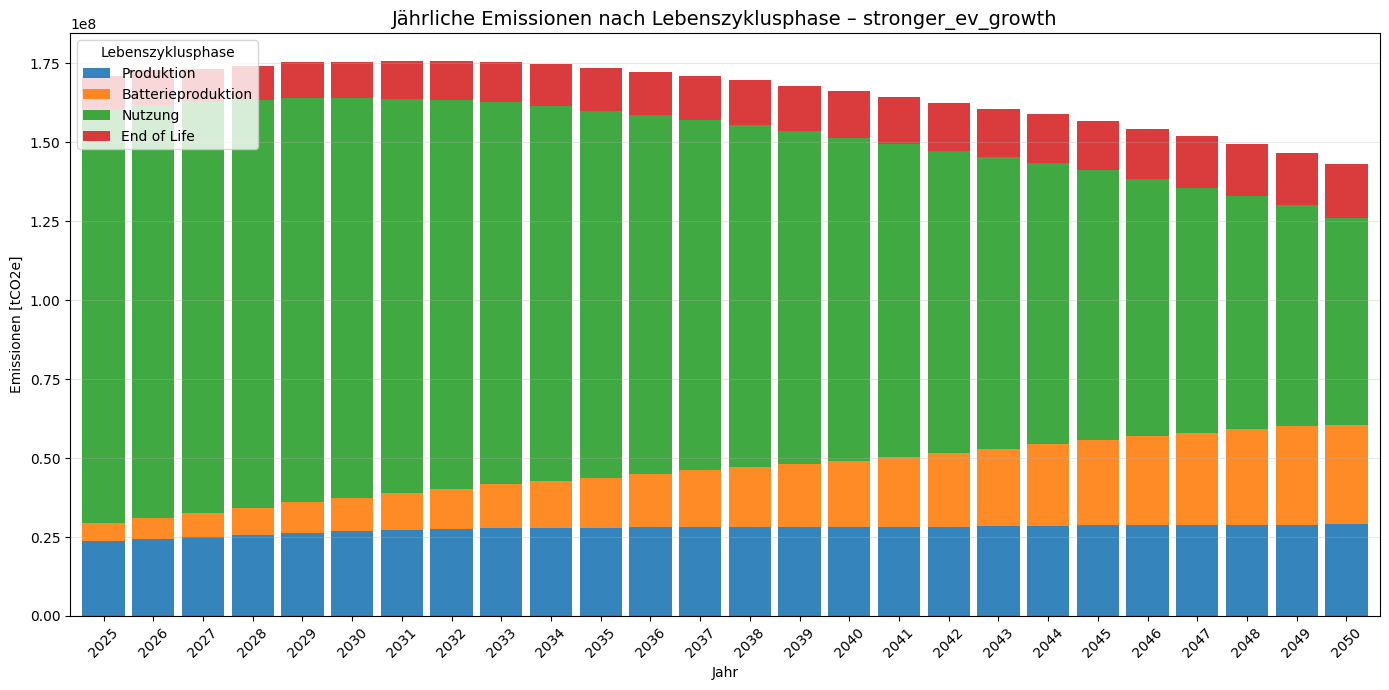

Diagramm gespeichert: Results\emissions_area_stronger_ev_growth.png


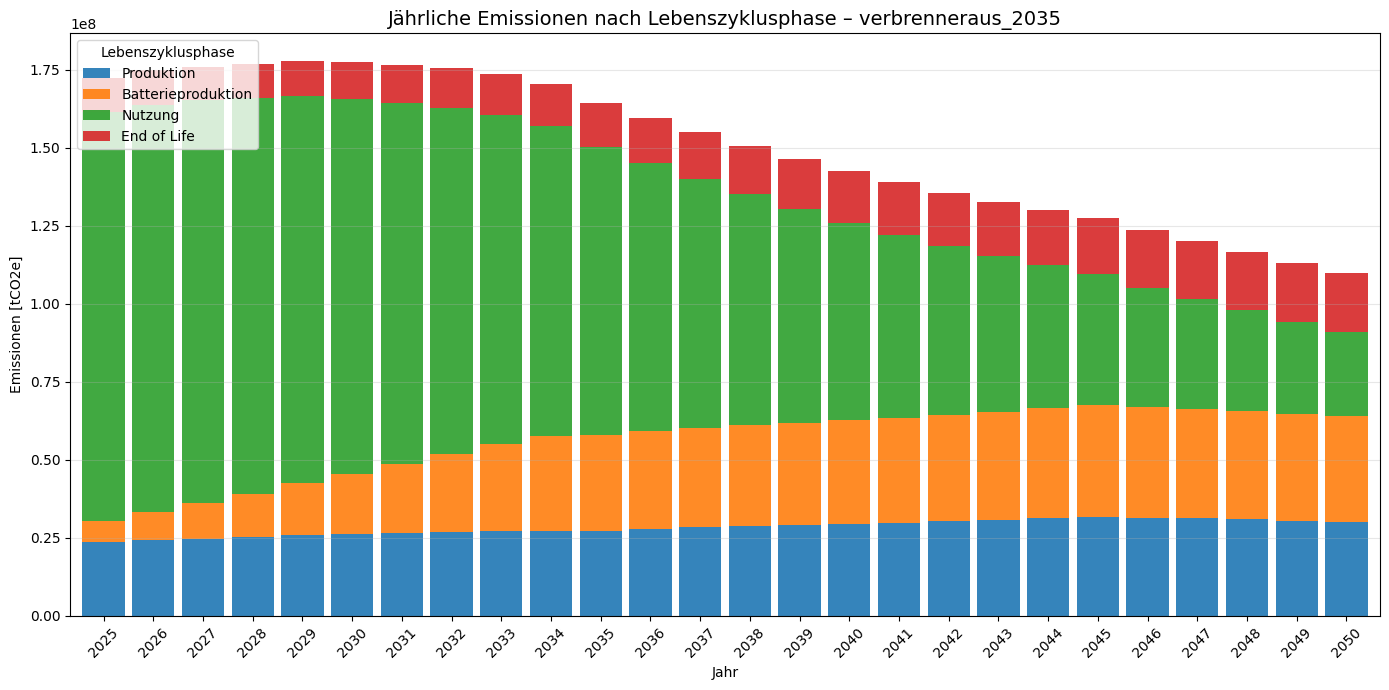

Diagramm gespeichert: Results\emissions_area_verbrenneraus_2035.png


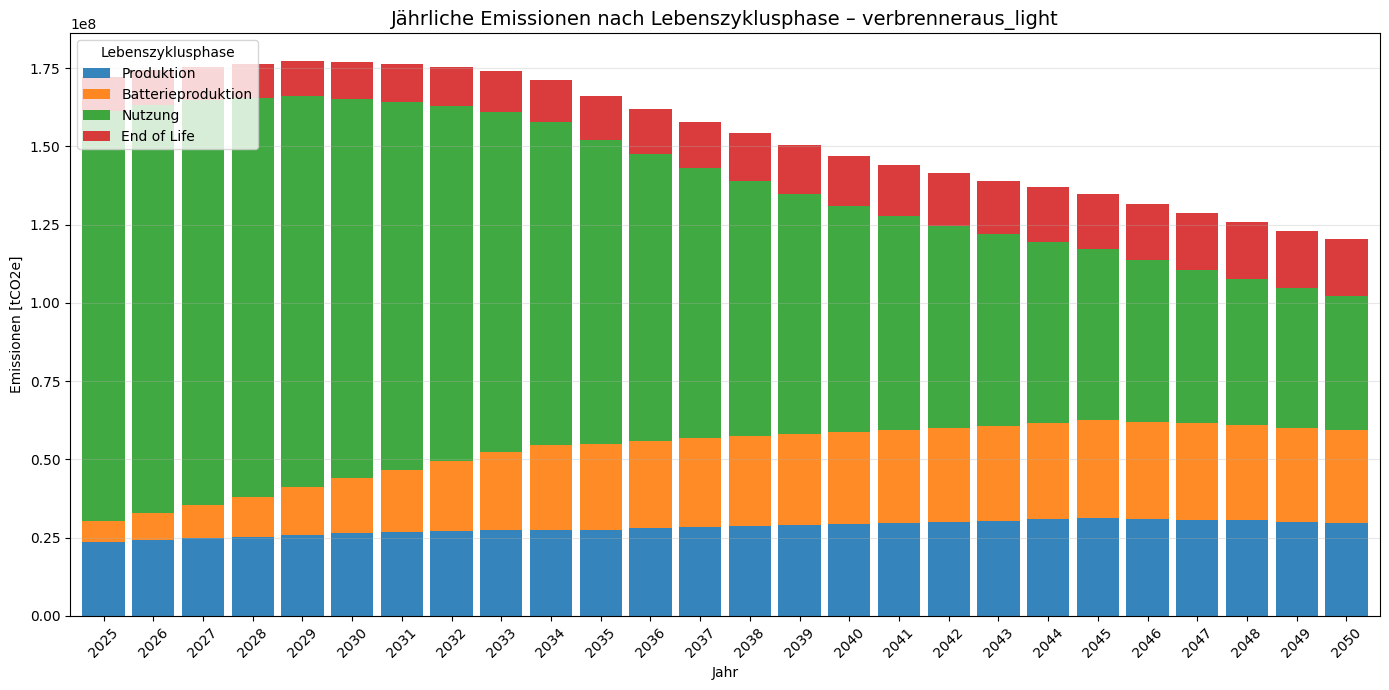

Diagramm gespeichert: Results\emissions_area_verbrenneraus_light.png


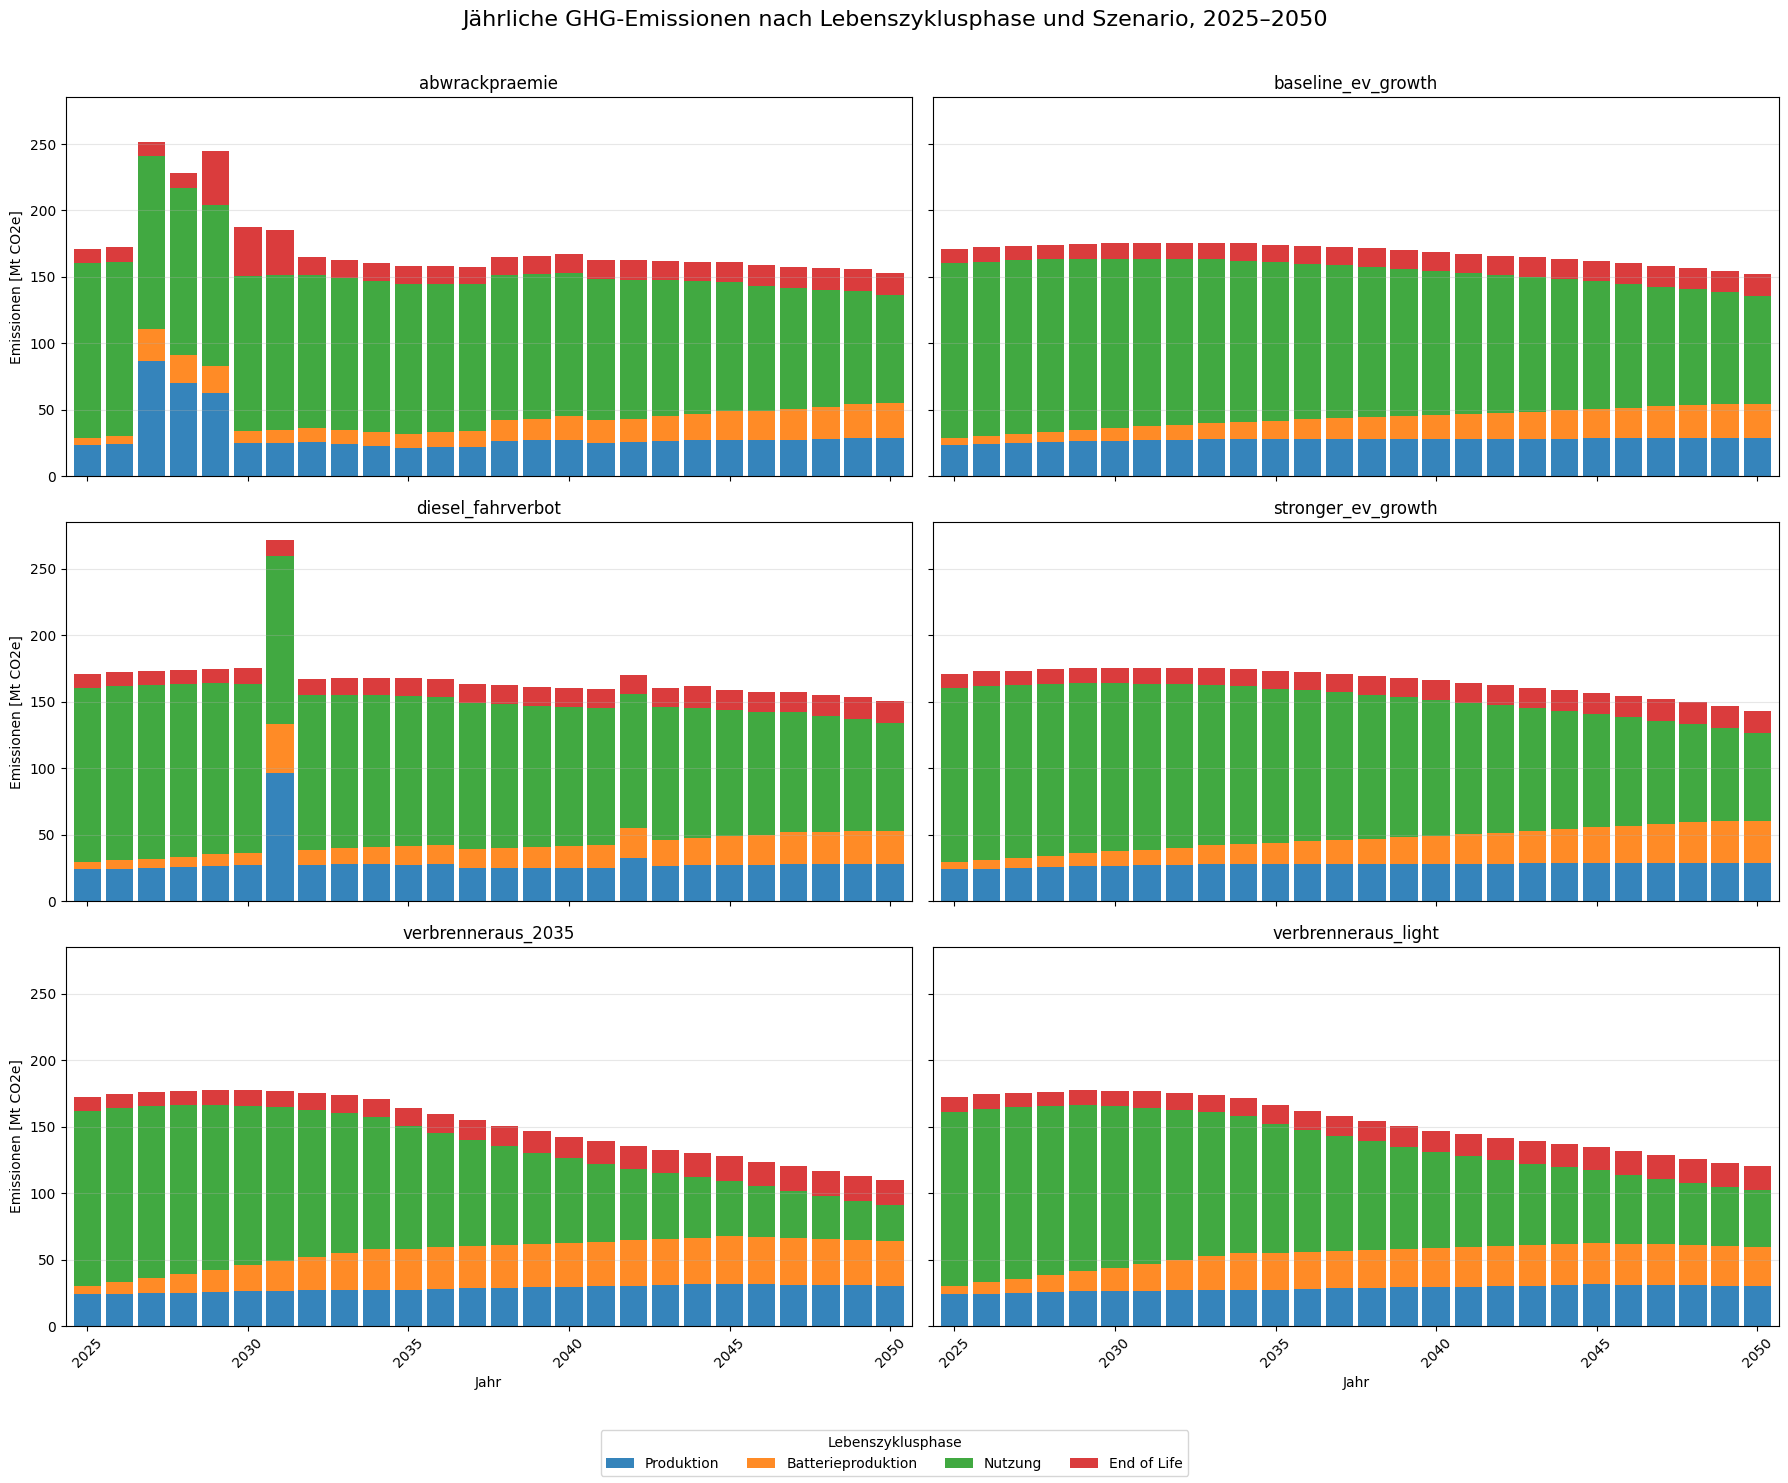

Gemeinsame Szenariengrafik gespeichert: Results\emissions_area_all_scenarios.png


In [2]:
# ============================================================
# Gestapeltes Flächendiagramm: Emissionen nach Lebenszyklusphase
# Datenquelle: bereits vorhandene Notebook-Variable emissions_by_phase
# ============================================================

from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Einstellungen
# ------------------------------------------------------------

RESULTS_DIR = Path("Results")

PHASE_ORDER = ["production", "battery_production", "use", "end_of_life"]

# Lesbare Bezeichnungen für die Legende
PHASE_LABELS = {
    "production": "Produktion",
    "battery_production": "Batterieproduktion",
    "use": "Nutzung",
    "end_of_life": "End of Life",
}


# ------------------------------------------------------------
# 2. Hilfsfunktion für sichere Dateinamen
# ------------------------------------------------------------

def make_safe_filename(text: str) -> str:
    """
    Wandelt einen Szenarionamen in einen sicheren Dateinamen um.

    Beispiele:
    'baseline' -> 'baseline'
    'Diesel Fahrverbot' -> 'diesel_fahrverbot'
    'Abwrackprämie' -> 'abwrackpraemie'
    """
    text = str(text).strip().lower()

    # Deutsche Sonderzeichen ersetzen
    text = (
        text
        .replace("ä", "ae")
        .replace("ö", "oe")
        .replace("ü", "ue")
        .replace("ß", "ss")
    )

    # Alles außer Buchstaben und Zahlen durch Unterstriche ersetzen
    text = re.sub(r"[^a-z0-9]+", "_", text)

    # Führende / abschließende Unterstriche entfernen
    text = text.strip("_")

    return text


# ------------------------------------------------------------
# 3. Prüfen, ob der Results-Ordner existiert
# ------------------------------------------------------------

if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Der Ordner '{RESULTS_DIR}' existiert nicht. "
        "Bitte führe zuerst die vorherigen Berechnungsschritte aus "
        "oder lege den Ordner an."
    )


# ------------------------------------------------------------
# 4. Daten direkt aus der Notebook-Variable übernehmen
# ------------------------------------------------------------

try:
    emissions = emissions_by_phase.copy()
except NameError:
    raise NameError(
        "Die Variable 'emissions_by_phase' existiert nicht im Notebook. "
        "Bitte führe zuerst die Zelle aus, in der emissions_by_phase erzeugt wird."
    )


# ------------------------------------------------------------
# 5. Benötigte Spalten prüfen
# ------------------------------------------------------------

required_columns = ["Szenario", "emission_year", "phase", "emissions_tco2e"]

missing_columns = [col for col in required_columns if col not in emissions.columns]

if missing_columns:
    raise ValueError(
        "In der Tabelle 'emissions_by_phase' fehlen folgende benötigte Spalten: "
        f"{missing_columns}\n"
        f"Vorhandene Spalten: {list(emissions.columns)}"
    )


# ------------------------------------------------------------
# 6. Numerische Spalten robust umwandeln
# ------------------------------------------------------------

emissions["emission_year"] = pd.to_numeric(
    emissions["emission_year"],
    errors="coerce",
)

emissions["emissions_tco2e"] = pd.to_numeric(
    emissions["emissions_tco2e"],
    errors="coerce",
)

# Zeilen ohne gültiges Jahr entfernen
emissions = emissions.dropna(subset=["emission_year"])

# Jahre als ganze Zahlen darstellen
emissions["emission_year"] = emissions["emission_year"].astype(int)

# Fehlende Emissionen als 0 behandeln
emissions["emissions_tco2e"] = emissions["emissions_tco2e"].fillna(0.0)


# ------------------------------------------------------------
# 7. Emissionen nach Szenario, Jahr und Phase aggregieren
# ------------------------------------------------------------

emissions_agg = (
    emissions
    .groupby(["Szenario", "emission_year", "phase"], as_index=False)
    ["emissions_tco2e"]
    .sum()
)


# ------------------------------------------------------------
# 8. Für jedes Szenario ein eigenes Diagramm erstellen
# ------------------------------------------------------------

for scenario_name, scenario_data in emissions_agg.groupby("Szenario"):

    # Pivot-Tabelle:
    # Zeilen = Jahre
    # Spalten = Lebenszyklusphasen
    # Werte = Emissionen in tCO2e
    plot_data = (
        scenario_data
        .pivot_table(
            index="emission_year",
            columns="phase",
            values="emissions_tco2e",
            aggfunc="sum",
            fill_value=0.0,
        )
        .sort_index()
    )

    # Falls eine Phase im Szenario fehlt, mit 0 ergänzen
    for phase in PHASE_ORDER:
        if phase not in plot_data.columns:
            plot_data[phase] = 0.0

    # Phasen in gewünschter Reihenfolge sortieren
    plot_data = plot_data[PHASE_ORDER]

    # --------------------------------------------------------
    # Diagramm erstellen
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(14, 7))

    plot_data.rename(columns=PHASE_LABELS).plot(
        kind="bar", stacked=True, width=0.85, ax=ax, alpha=0.9
    )

    # --------------------------------------------------------
    # Diagramm beschriften
    # --------------------------------------------------------

    ax.set_title(
        f"Jährliche Emissionen nach Lebenszyklusphase – {scenario_name}",
        fontsize=14,
    )

    ax.set_xlabel("Jahr")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Emissionen [tCO2e]")

    ax.legend(
        title="Lebenszyklusphase",
        loc="upper left",
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.3,
    )

    fig.tight_layout()

    # --------------------------------------------------------
    # Diagramm speichern
    # --------------------------------------------------------

    safe_scenario_name = make_safe_filename(scenario_name)
    output_file = RESULTS_DIR / f"emissions_area_{safe_scenario_name}.png"

    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Diagramm gespeichert: {output_file}")

# Gemeinsame 3x2-Abbildung für den direkten Vergleich aller sechs Szenarien
scenario_order = [
    "abwrackpraemie", "baseline_ev_growth", "diesel_fahrverbot",
    "stronger_ev_growth", "verbrenneraus_2035", "verbrenneraus_light",
]
available_scenarios = set(emissions_agg["Szenario"].unique())
scenario_order = [name for name in scenario_order if name in available_scenarios]
scenario_order += sorted(available_scenarios.difference(scenario_order))

fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=True, sharey=True)
axes = axes.flatten()
for ax, scenario_name in zip(axes, scenario_order):
    scenario_data = emissions_agg.loc[emissions_agg["Szenario"].eq(scenario_name)]
    panel_data = (scenario_data.pivot_table(
        index="emission_year", columns="phase", values="emissions_tco2e",
        aggfunc="sum", fill_value=0.0,
    ).sort_index())
    for phase in PHASE_ORDER:
        if phase not in panel_data.columns:
            panel_data[phase] = 0.0
    panel_data = panel_data[PHASE_ORDER] / 1_000_000
    panel_data.rename(columns=PHASE_LABELS).plot(
        kind="bar", stacked=True, width=0.85, ax=ax, legend=False, alpha=0.9
    )
    ax.set_title(scenario_name)
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Emissionen [Mt CO2e]")
    tick_positions = np.arange(0, len(panel_data), 5)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(panel_data.index[tick_positions], rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
for ax in axes[len(scenario_order):]:
    ax.set_visible(False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Lebenszyklusphase", loc="lower center", ncol=4)
fig.suptitle("Jährliche GHG-Emissionen nach Lebenszyklusphase und Szenario, 2025–2050", fontsize=16)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
all_scenarios_output = RESULTS_DIR / "emissions_area_all_scenarios.png"
fig.savefig(all_scenarios_output, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gemeinsame Szenariengrafik gespeichert: {all_scenarios_output}")

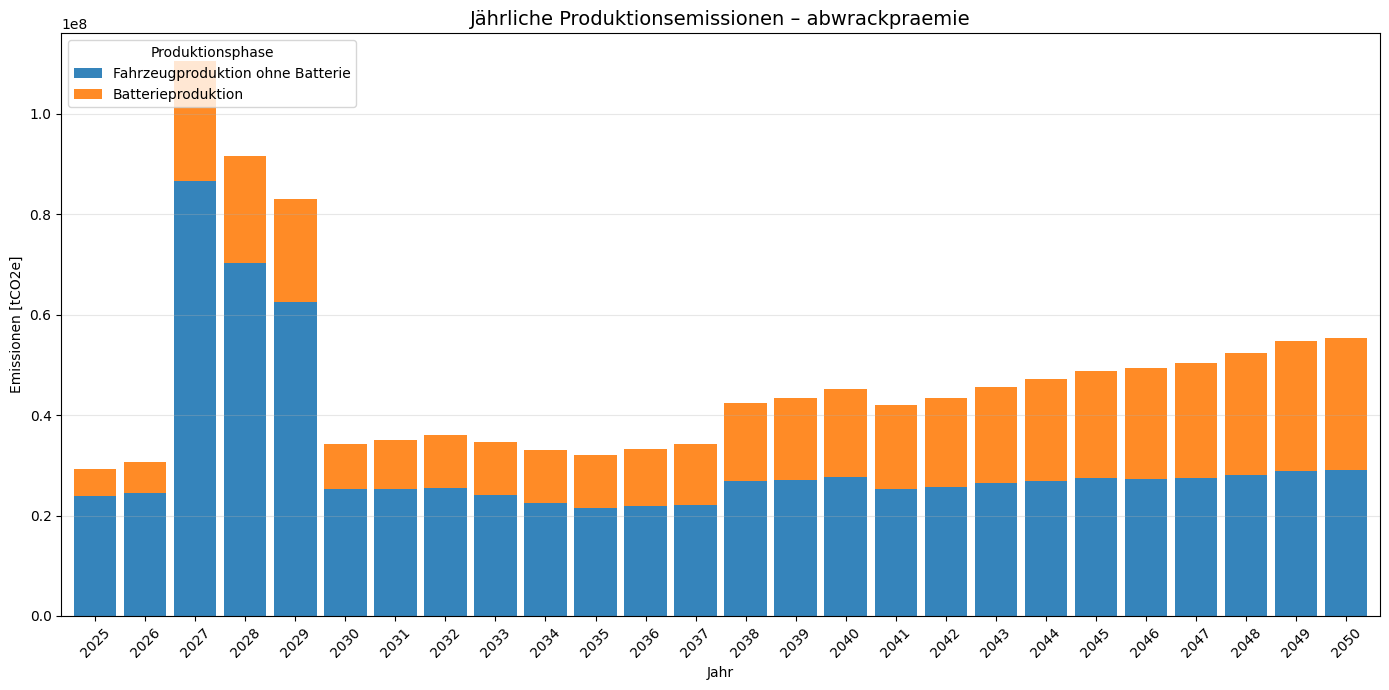

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_abwrackpraemie.png


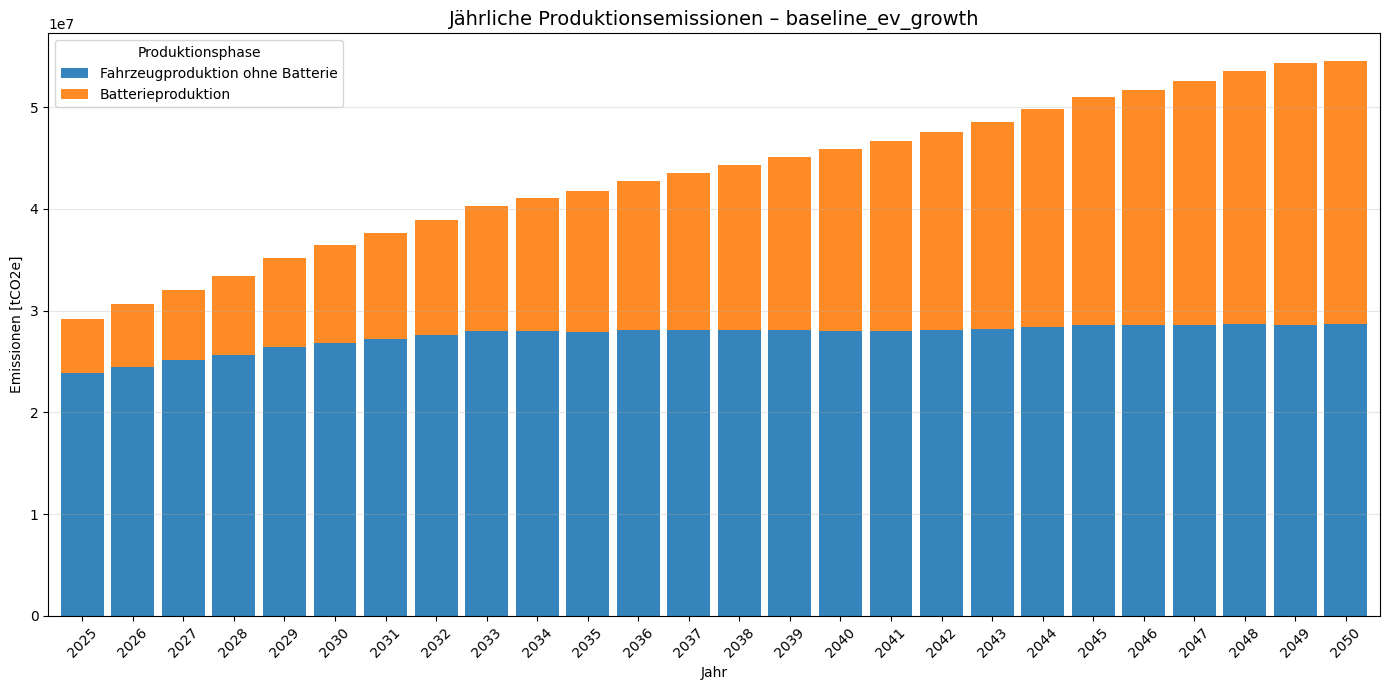

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_baseline_ev_growth.png


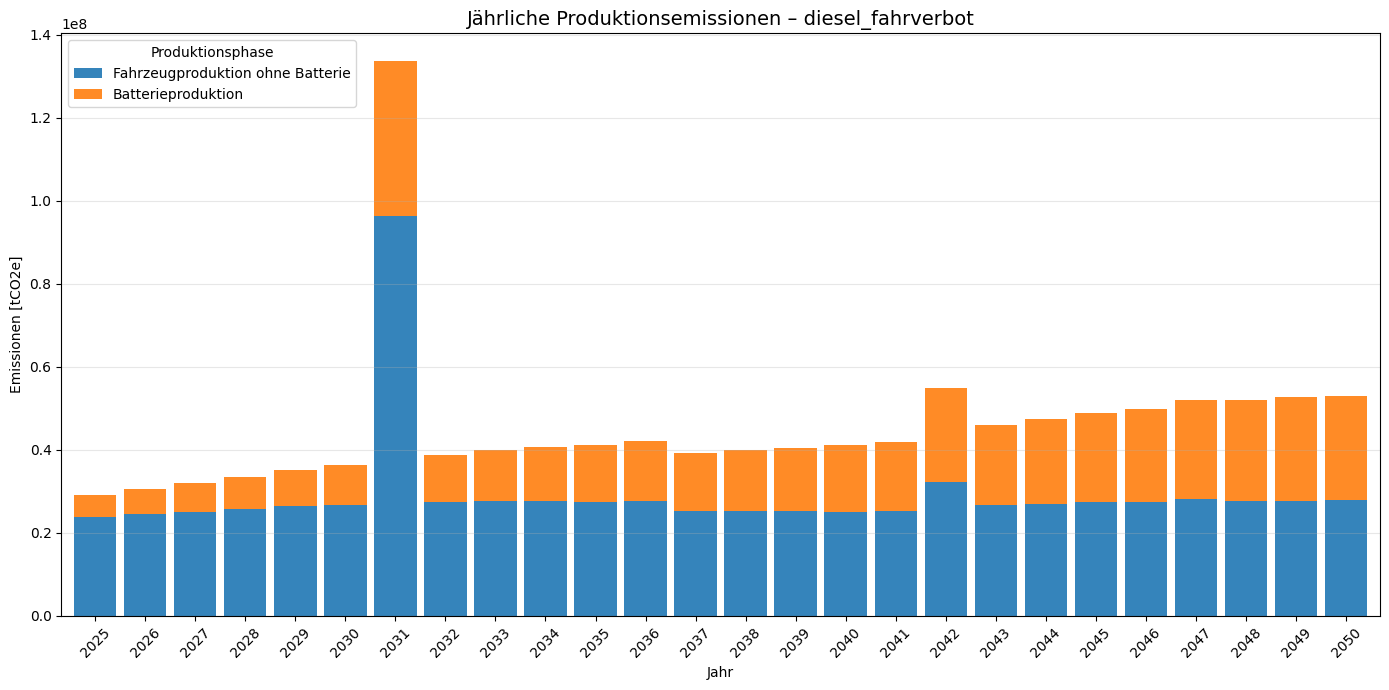

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_diesel_fahrverbot.png


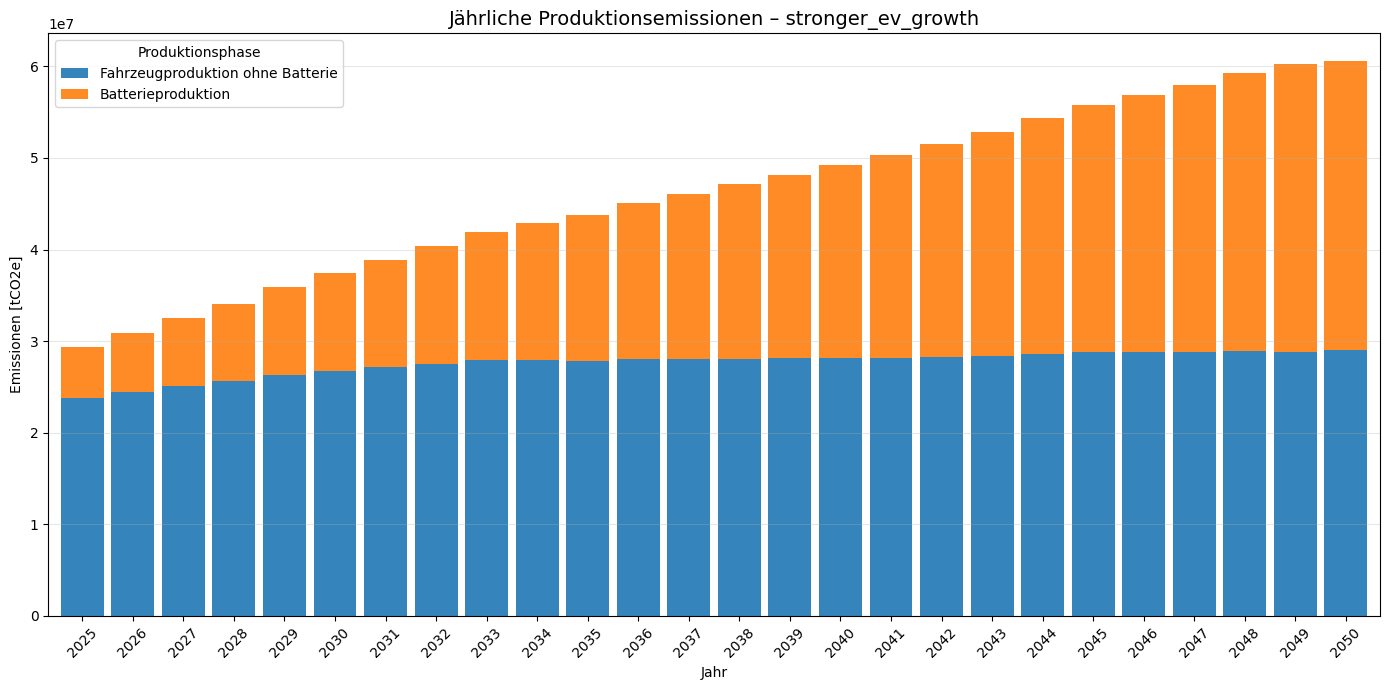

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_stronger_ev_growth.png


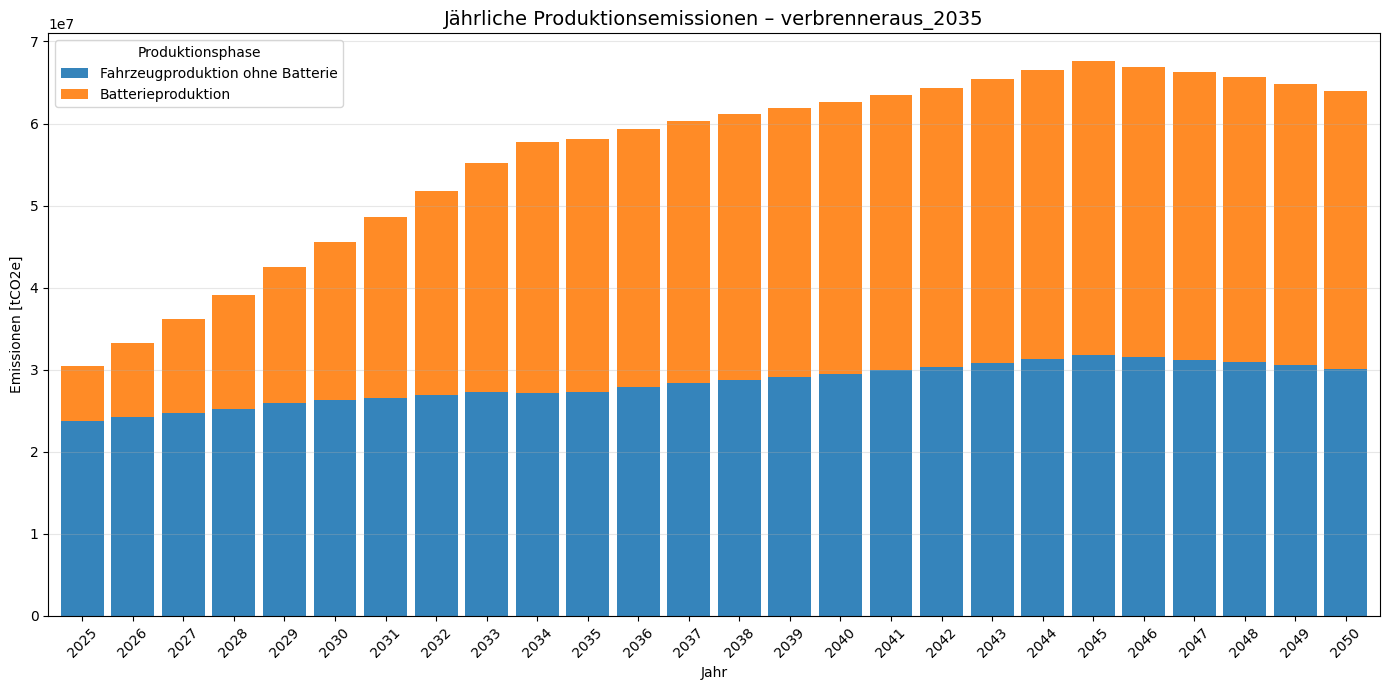

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_verbrenneraus_2035.png


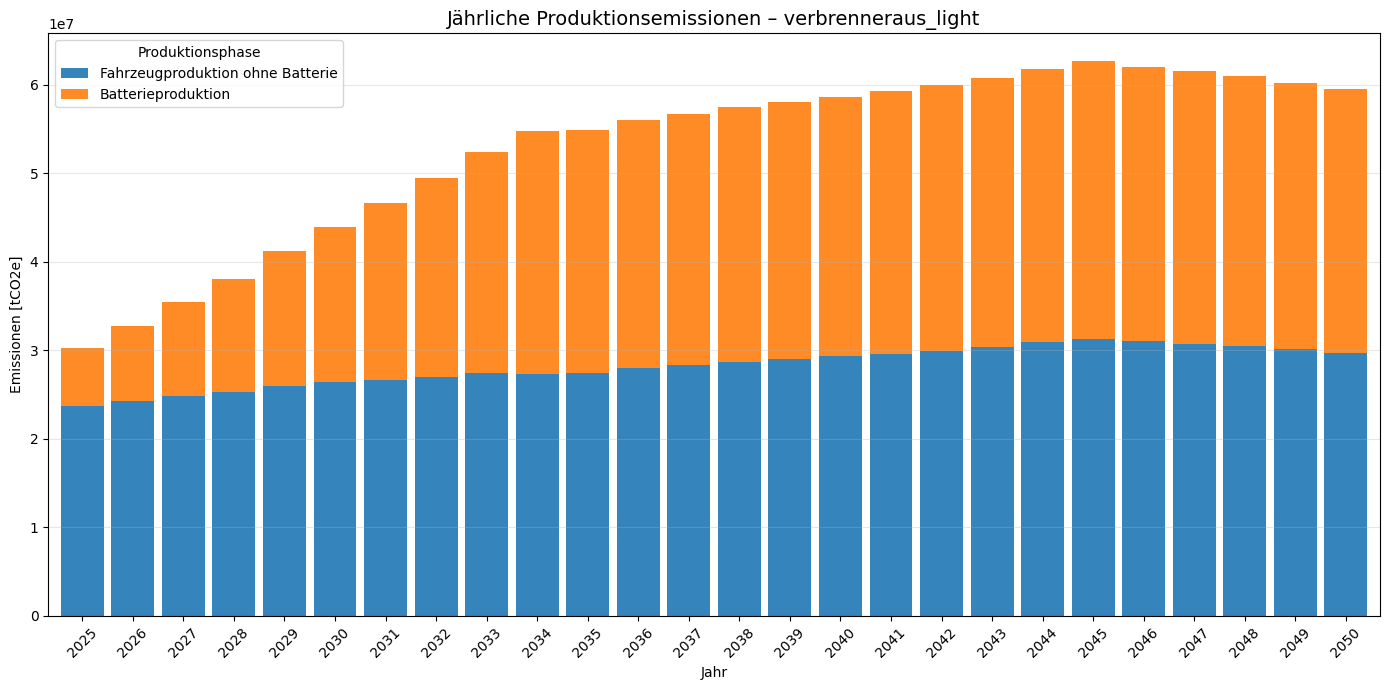

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_verbrenneraus_light.png


In [3]:
# ============================================================
# Zusätzliches Flächendiagramm: Produktionsphasen getrennt
# Die bestehenden Lebenszyklusdiagramme bleiben unverändert.
# ============================================================

PRODUCTION_PHASE_ORDER = ["production", "battery_production"]
PRODUCTION_PHASE_LABELS = {
    "production": "Fahrzeugproduktion ohne Batterie",
    "battery_production": "Batterieproduktion",
}

production_plot_emissions = emissions_by_phase[
    emissions_by_phase["phase"].isin(PRODUCTION_PHASE_ORDER)
].copy()
production_plot_agg = (
    production_plot_emissions
    .groupby(["Szenario", "emission_year", "phase"], as_index=False)["emissions_tco2e"]
    .sum()
)

for scenario_name, scenario_data in production_plot_agg.groupby("Szenario"):
    plot_data = (
        scenario_data
        .pivot_table(
            index="emission_year", columns="phase",
            values="emissions_tco2e", aggfunc="sum", fill_value=0.0,
        )
        .sort_index()
    )
    for phase in PRODUCTION_PHASE_ORDER:
        if phase not in plot_data.columns:
            plot_data[phase] = 0.0
    plot_data = plot_data[PRODUCTION_PHASE_ORDER]

    fig, ax = plt.subplots(figsize=(14, 7))
    plot_data.rename(columns=PRODUCTION_PHASE_LABELS).plot(
        kind="bar", stacked=True, width=0.85, ax=ax, alpha=0.9
    )
    ax.set_title(f"Jährliche Produktionsemissionen – {scenario_name}", fontsize=14)
    ax.set_xlabel("Jahr")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Emissionen [tCO2e]")
    ax.legend(title="Produktionsphase", loc="upper left")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()

    safe_scenario_name = make_safe_filename(scenario_name)
    output_file = RESULTS_DIR / f"emissions_area_production_split_{safe_scenario_name}.png"
    fig.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Zusätzliches Produktionsdiagramm gespeichert: {output_file}")


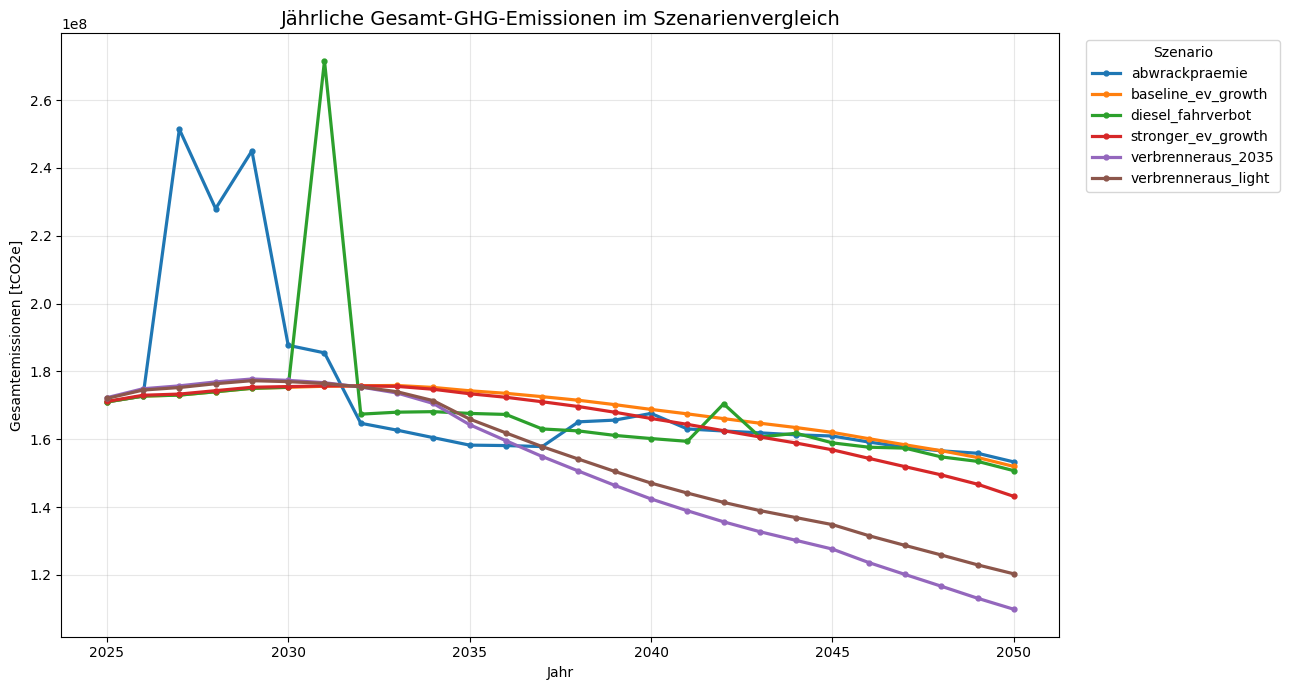

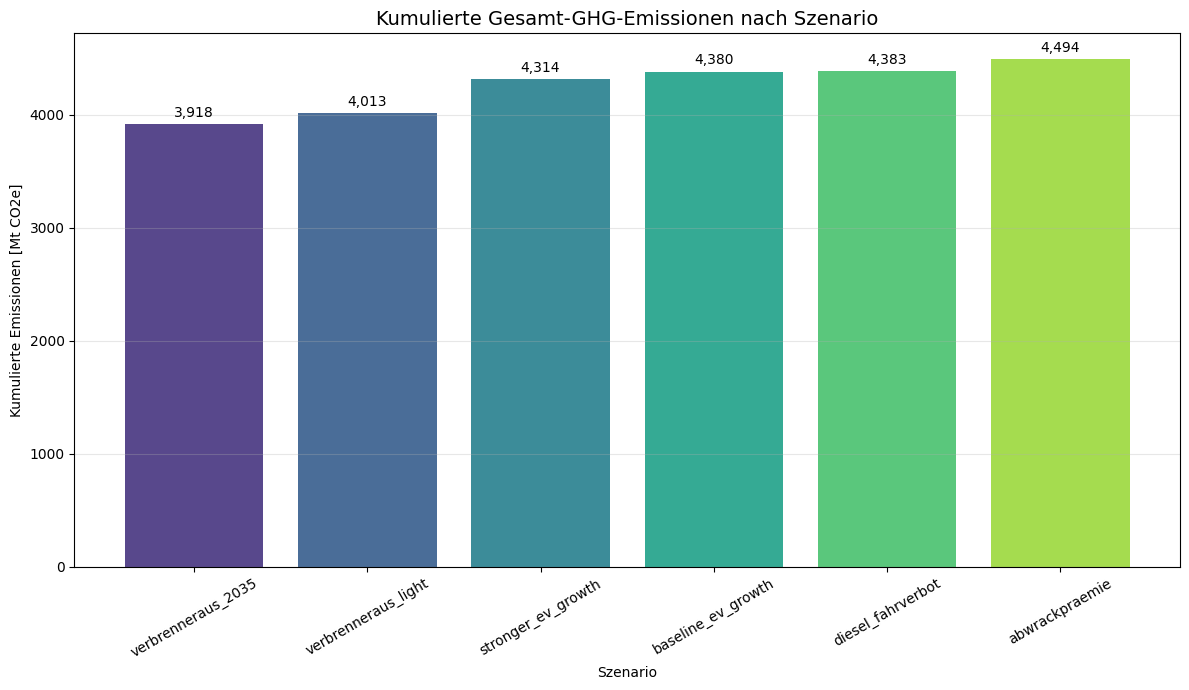

,Szenario,total_emissions_tco2e,total_emissions_MtCO2e
4,verbrenneraus_2035,3.917796e+09,3917.796
5,verbrenneraus_light,4.012629e+09,4012.629
3,stronger_ev_growth,4.313893e+09,4313.893
1,baseline_ev_growth,4.379908e+09,4379.908
2,diesel_fahrverbot,4.383116e+09,4383.116
0,abwrackpraemie,4.493970e+09,4493.970


Vergleichsgrafik gespeichert: Results\emissions_total_scenarios_comparison.png
Kumulierte Vergleichsgrafik gespeichert: Results\emissions_cumulative_scenarios_comparison.png
Aggregierte Emissionstabellen wurden im Results-Ordner gespeichert.


In [4]:
# ============================================================
# Vergleich der gesamten GHG-Emissionen aller Szenarien
# Einschließlich Fahrzeug- und Batterieproduktion, Nutzung und EoL
# ============================================================

emissions_summary_by_year_phase = (
    emissions_by_phase
    .groupby(["Szenario", "emission_year", "phase"], as_index=False)["emissions_tco2e"]
    .sum()
)
emissions_summary_by_year_total = (
    emissions_by_phase
    .groupby(["Szenario", "emission_year"], as_index=False)["emissions_tco2e"]
    .sum()
    .rename(columns={"emissions_tco2e": "total_emissions_tco2e"})
)
emissions_summary_total_by_scenario = (
    emissions_summary_by_year_total
    .groupby("Szenario", as_index=False)["total_emissions_tco2e"]
    .sum()
    .sort_values("total_emissions_tco2e")
)

emissions_by_phase.to_csv(OUT_EMISSIONS_BY_PHASE, sep=CSV_SEP, encoding=CSV_ENCODING, index=False)
emissions_summary_by_year_phase.to_csv(OUT_SUMMARY_YEAR_PHASE, sep=CSV_SEP, encoding=CSV_ENCODING, index=False)
emissions_summary_by_year_total.to_csv(OUT_SUMMARY_YEAR_TOTAL, sep=CSV_SEP, encoding=CSV_ENCODING, index=False)
emissions_summary_total_by_scenario.to_csv(OUT_SUMMARY_TOTAL_SCENARIO, sep=CSV_SEP, encoding=CSV_ENCODING, index=False)

comparison = emissions_summary_by_year_total.pivot(
    index="emission_year", columns="Szenario", values="total_emissions_tco2e"
).sort_index()
fig, ax = plt.subplots(figsize=(13, 7))
comparison.plot(kind="line", ax=ax, linewidth=2.3, marker="o", markersize=3.5)
ax.set_title("Jährliche Gesamt-GHG-Emissionen im Szenarienvergleich", fontsize=14)
ax.set_xlabel("Jahr")
ax.set_ylabel("Gesamtemissionen [tCO2e]")
ax.tick_params(axis="x", rotation=0)
ax.grid(True, alpha=0.3)
ax.legend(title="Szenario", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
comparison_output = RESULTS_DIR / "emissions_total_scenarios_comparison.png"
fig.savefig(comparison_output, dpi=300, bbox_inches="tight")
plt.show()

# Kumulierte Gesamtemissionen über den gesamten Betrachtungszeitraum
cumulative_plot = emissions_summary_total_by_scenario.copy()
cumulative_plot["total_emissions_MtCO2e"] = cumulative_plot["total_emissions_tco2e"] / 1_000_000
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(
    cumulative_plot["Szenario"], cumulative_plot["total_emissions_MtCO2e"],
    color=plt.cm.viridis(np.linspace(0.15, 0.85, len(cumulative_plot))), alpha=0.9,
)
ax.bar_label(bars, labels=[f"{value:,.0f}" for value in cumulative_plot["total_emissions_MtCO2e"]], padding=3)
ax.set_title("Kumulierte Gesamt-GHG-Emissionen nach Szenario", fontsize=14)
ax.set_xlabel("Szenario")
ax.set_ylabel("Kumulierte Emissionen [Mt CO2e]")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
cumulative_output = RESULTS_DIR / "emissions_cumulative_scenarios_comparison.png"
fig.savefig(cumulative_output, dpi=300, bbox_inches="tight")
plt.show()

display(emissions_summary_total_by_scenario.assign(
    total_emissions_MtCO2e=lambda x: x["total_emissions_tco2e"] / 1_000_000
).round(3))
print(f"Vergleichsgrafik gespeichert: {comparison_output}")
print(f"Kumulierte Vergleichsgrafik gespeichert: {cumulative_output}")
print("Aggregierte Emissionstabellen wurden im Results-Ordner gespeichert.")
